<a href="https://colab.research.google.com/github/PutriAqila/Analisis-Deret-Waktu/blob/main/Tugas_STA1542_Minggu_2_Kecenderungan_Deret.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Kecenderungan dalam Deret Waktu

Misalkan suatu deret waktu memiliki fungsi nilaitengah konstan. Model untuk deret waktu tersebut dapat dituliskan sebagai berikut:

$Y_t=\mu_t+X_t$

dengan $E(X_t)=0$ untuk semua $t$.

## Kecenderungan Linear

Deret dikatakan memiliki kecenderungan linear dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t$

Berikut simulasi deret yang memiliki kecenderungan linear dalam waktu.

In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [67]:
# membangkitkan data waktu dalam bentuk array (misalnya, 100 bulan)
np.random.seed(1029)
n = 100
t = np.arange(n)

# Membuat deret dengan kecenderungan linear
beta0 = 10 + 29
beta1 = 0.5 * 29
deret = beta0 + beta1*t

# Menambahkan ingar acak
noise = np.random.normal(scale=2, size=n)  # Noise dengan standar deviasi 2
time_series = deret + noise  # Menggabungkan tren dengan noise

# Membuat DataFrame untuk menyimpan data
df = pd.DataFrame({"Time": pd.date_range(start="2017-01-01", periods=100, freq="M"),
                   "Value": time_series})

In [68]:
df["Trend"] = deret
df.head()

,Time,Value,Trend
0,2017-01-31,38.800743,39.0
1,2017-02-28,52.486475,53.5
2,2017-03-31,69.743319,68.0
3,2017-04-30,82.886707,82.5
4,2017-05-31,97.273688,97.0


In [69]:
# Plot deret waktu dengan tren linear
fig = go.Figure()

# Plot data aktual
fig.add_trace(
    go.Scatter(
        x=df["Time"],
        y=df["Value"],
        mode="lines+markers",
        name="Deret Aktual",
        line=dict(color="#1f77b4")
    )
)

# Plot tren sebenarnya
fig.add_trace(
    go.Scatter(
        x=df["Time"],
        y=df["Trend"],
        mode="lines",
        name="Trend Linear",
        line=dict(
            color="#ff7f0e",
            width=3
        )
    )
)
fig.update_layout(
    title="Simulasi Deret Waktu dengan Kecenderungan Linear",
    xaxis_title="Waktu",
    yaxis_title="Nilai Deret",
    template="simple_white",
    width=900,
    height=450
)
fig.show()

***Apakah ada korelasi antar pengamatan?***

Berdasarkan hasil perhitungan, korelasi antara waktu dan nilai deret sangat mendekati 1, yang menunjukkan adanya hubungan linear positif yang sangat kuat. Artinya, nilai deret cenderung meningkat seiring bertambahnya waktu akibat adanya kecenderungan linear. Namun, perhitungan tersebut merupakan korelasi antara waktu dan nilai deret, bukan korelasi antar pengamatan deret waktu. Untuk mengevaluasi korelasi antar pengamatan, yaitu hubungan antara $Y_t$ dengan $Y_{t-k}$, diperlukan pemeriksaan autokorelasi seperti ACF. Dengan demikian, korelasi yang tinggi pada bagian ini terutama menunjukkan kuatnya komponen tren pada deret.

In [70]:
# Konversi kolom Time menjadi angka (misalnya jumlah bulan sejak periode pertama)
df["Time_Numeric"] = (df["Time"].dt.to_period("M") - df["Time"].dt.to_period("M").min()).apply(lambda x: x.n)

# Hitung korelasi antara Time_Numeric dan Value
correlation = df["Time_Numeric"].corr(df["Value"])

print(f"Nilai korelasi antara Time dan Value: {correlation:.4f}")

Nilai korelasi antara Time dan Value: 1.0000


In [71]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df["Time_Numeric"]
Y = df["Value"]

#memanggil package statsmodels
import statsmodels.api as sm

# Tambahkan konstanta (intercept) ke model regresi
X = sm.add_constant(X)

# Buat dan jalankan model regresi
model = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.169e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.24e-228
Time:                        13:35:30   Log-Likelihood:                -212.70
No. Observations:                 100   AIC:                             429.4
Df Residuals:                      98   BIC:                             434.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           38.7820      0.407     95.272   

***Bagaimana hasil pengepasan model regresi dibandingkan dengan nilai parameter asli?***

Hasil pengepasan model regresi linear menunjukkan bahwa nilai parameter hasil estimasi sangat dekat dengan parameter asli yang digunakan untuk membangkitkan data.

Nilai estimasi $\hat{\beta_0}$ hanya berbeda sekitar **0.218** dari nilai sebenarnya, sedangkan estimasi $\hat{\beta_1}$ hampir sama dengan nilai parameter asli dengan selisih yang sangat kecil.

Hal ini menunjukkan bahwa model regresi linear mampu mengestimasi hubungan antara waktu dan nilai deret dengan sangat baik. Perbedaan kecil antara parameter asli dan hasil estimasi disebabkan oleh adanya komponen noise/ingar acak yang ditambahkan pada proses simulasi data.


---


***Apakah model regresi yang dipaskan sudah bagus?***

Model regresi linear yang dipaskan sudah sangat baik dalam menggambarkan deret dengan kecenderungan linear. Hal ini ditunjukkan oleh nilai R-squared yang sangat tinggi, parameter hasil estimasi yang mendekati nilai asli, koefisien waktu yang signifikan, serta residual yang memenuhi asumsi dasar regresi. Dengan demikian, model regresi linear mampu menangkap pola tren pada deret yang dibangkitkan dengan baik.

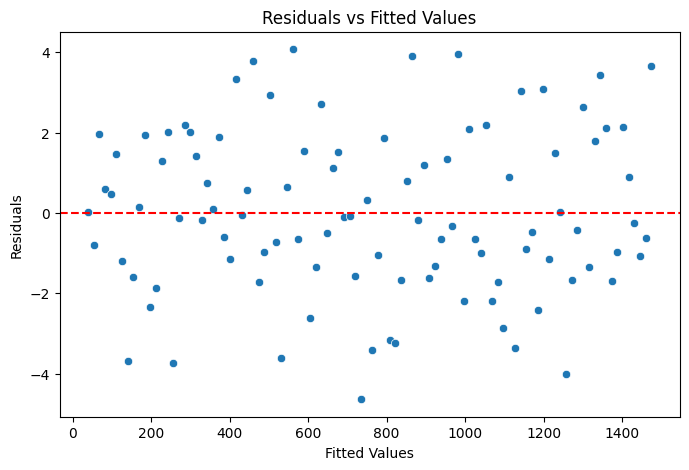

In [72]:
# Analisis Sisaan Model
import seaborn as sns

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


***Apa interpretasi dari plot tersebut?***

Berdasarkan plot Residuals vs Fitted Values, terlihat bahwa residual menyebar secara acak di sekitar garis nol tanpa membentuk pola tertentu. Penyebaran residual terjadi baik pada nilai fitted yang rendah maupun tinggi dengan rentang yang relatif sama. Hal ini menunjukkan bahwa model regresi linear telah mampu menangkap pola kecenderungan linear pada data.

Selain itu, tidak terlihat indikasi pelanggaran linearitas maupun heteroskedastisitas berdasarkan plot. Kesimpulan mengenai homoskedastisitas kemudian diperkuat oleh uji Breusch-Pagan. Dengan kata lain, besar kecilnya kesalahan prediksi tidak dipengaruhi oleh nilai prediksi model. Maka model regresi linear sudah mampu menggambarkan hubungan antara waktu dan nilai deret dengan baik.

Hasil ini mendukung bahwa hasil estimasi parameter regresi mendekati parameter asli yang digunakan dalam simulasi, yaitu $\beta_0=39$ dan $\beta_1=14.5$.

In [74]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")


P-value Breusch-Pagan Test: 0.4499


***Apa kesimpulan dari nilai uji Breusch Pagan tersebut?***

**Hipotesis pengujian Breusch-Pagan**
*   $H_0$: Tidak terdapat heteroskedastisitas (residual memiliki ragam yang konstan / homoskedastisitas)
*   $H_1$: Terdapat heteroskedastisitas (ragam residual tidak konstan)

Karena diperoleh:
$$ p\text{-value}=0.4499 > 0.05 $$
maka gagal menolak $H_0$.

Hal ini menunjukkan bahwa tidak terdapat cukup bukti untuk menyatakan adanya heteroskedastisitas pada residual. Dengan demikian, residual pada model regresi linear memiliki ragam yang relatif konstan (homoskedastisitas), sehingga asumsi kesamaan ragam residual telah terpenuhi.

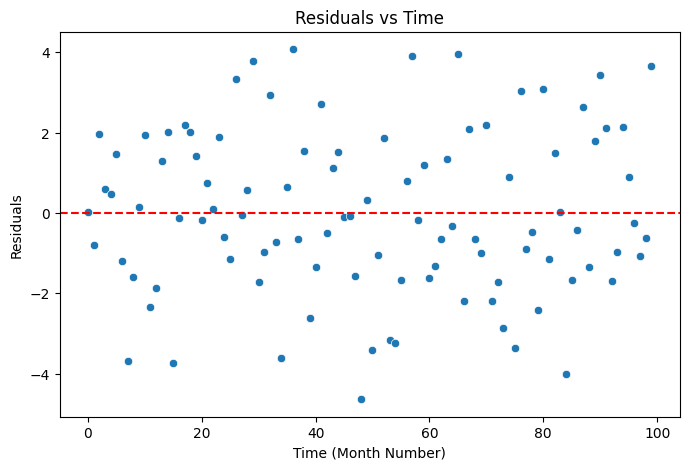

In [75]:
# Plot residual vs time
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Time_Numeric"], y=model.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time (Month Number)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


<Figure size 800x500 with 0 Axes>

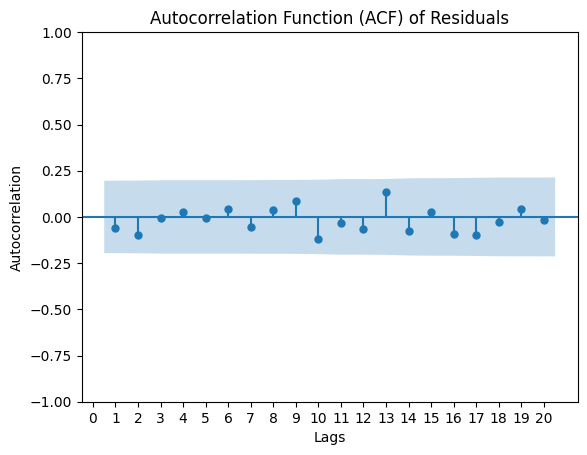

In [76]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8, 5))
plot_acf(model.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()


***Apa yang dapat Anda simpulkan dari plot di atas?***

* Plot residual terhadap waktu menunjukkan bahwa residual menyebar secara acak di sekitar nilai nol dan tidak membentuk pola tertentu. Hal ini mengindikasikan bahwa tidak terdapat komponen tren atau pola waktu yang belum dijelaskan oleh model regresi linear.

* Berdasarkan plot ACF residual, tidak terdapat nilai autokorelasi yang signifikan pada berbagai lag. Hal ini menunjukkan bahwa residual bersifat acak dan tidak terdapat hubungan antar pengamatan yang tersisa setelah model regresi diterapkan.

In [77]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(model.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)


Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    0.366625   0.544850
2    1.398276   0.497014
3    1.403716   0.704664
4    1.466130   0.832624
5    1.470778   0.916417
6    1.688313   0.946020
7    1.987270   0.960542
8    2.135568   0.976571
9    3.009768   0.963906
10   4.696798   0.910491
11   4.809301   0.940049
12   5.311805   0.946746
13   7.528080   0.872930
14   8.220935   0.877501
15   8.316628   0.910462
16   9.303470   0.900392
17  10.438824   0.884208
18  10.544292   0.912686
19  10.767919   0.931398


***Apa kesimpulan dari hasil uji Ljung-Box tersebut?***

**Hipotesis**
*   $H_0$: Tidak terdapat autokorelasi pada residual
*   $H_1$: Terdapat autokorelasi pada residual

Karena seluruh nilai p-value pada berbagai lag lebih besar dari 0.05, maka gagal menolak $H_0$.

Hal ini menunjukkan bahwa tidak terdapat bukti adanya autokorelasi yang signifikan pada residual model. Dengan demikian, residual model regresi linear dapat dianggap independen terhadap waktu dan memenuhi asumsi tidak adanya korelasi antar pengamatan. Hasil ini mendukung bahwa model regresi linear telah mampu menangkap komponen kecenderungan linear pada deret dengan baik.

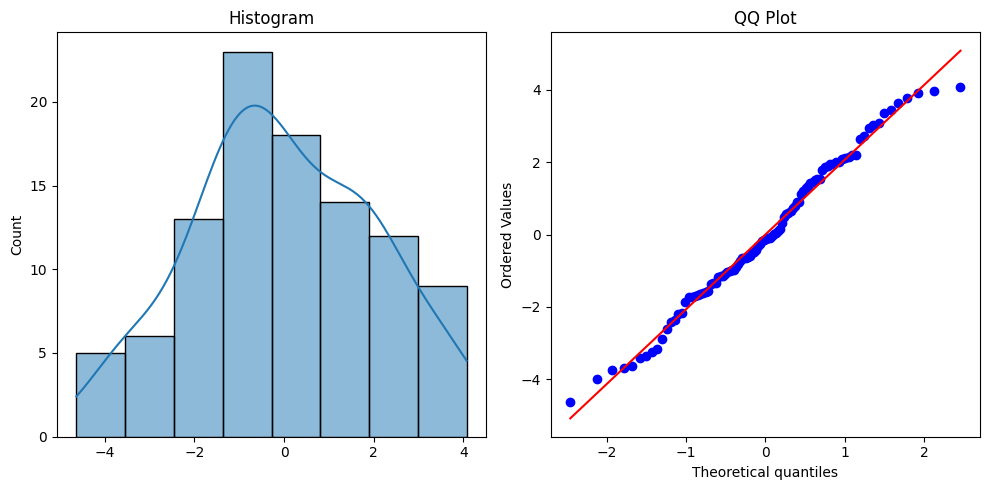

In [78]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(model.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

***Apa kesimpulan Anda berdasarkan plot di atas?***

Berdasarkan histogram residual dan QQ Plot, residual model regresi linear menunjukkan pola yang mendekati distribusi normal. Histogram memperlihatkan bentuk distribusi yang relatif simetris di sekitar nilai tengah (mendekati 0), sedangkan QQ Plot menunjukkan sebagian besar titik mengikuti garis diagonal. Meskipun terdapat sedikit penyimpangan pada bagian ujung (tail) yang masih dapat dianggap wajar.

In [79]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model.resid)
print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat}, p-value = {shapiro_p_value}")

Shapiro-Wilk Test: Statistics = 0.9850525663855669, p-value = 0.3203737178090624


***Apakah kesimpulan Anda dari nilai uji Shapiro Wilk sama dengan kesimpulan Anda berdasarkan plot?***

**Hipotesis**
*   $H_0$: Residual berdistribusi normal
*   $H_1$: Residual tidak berdistribusi normal

Karena diperoleh:

$$ p\text{-value}=0.3204 > 0.05 $$

maka gagal menolak $H_0$.

Artinya, secara statistik tidak terdapat bukti yang cukup untuk menyatakan bahwa residual tidak berdistribusi normal.


## Kecenderungan Kuadratik

Deret dikatakan memiliki kecenderungan kuadratik dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t+\beta_2t^2$


In [83]:
# Menentukan parameter simulasi
np.random.seed(1029)
n_periods = 120
beta_0, beta_1, beta_2= 50 + 29, 0.5 * 29, 0.02 * 29
noise = np.random.normal(0, 10, n_periods)
time = np.arange(n_periods)

# Membuat komponen kuadratik
quadratic_component = beta_0 + beta_1 * time + beta_2 * time**2

# Menambahkan noise untuk membuat data lebih realistis
data = quadratic_component + noise

# Membuat DataFrame
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')
df_quad = pd.DataFrame({'Date': dates, 'Value': data})

In [84]:
df_quad["Quadratic_Trend"] = quadratic_component
df_quad.head()

,Date,Value,Quadratic_Trend
0,2010-01-31,78.003717,79.00
1,2010-02-28,89.012373,94.08
2,2010-03-31,119.036593,110.32
3,2010-04-30,129.653535,127.72
4,2010-05-31,147.648438,146.28


In [85]:
# Plot hasil simulasi deret waktu dengan kecenderungan kuadratik
fig = go.Figure()

# Data aktual
fig.add_trace(
    go.Scatter(
        x=df_quad["Date"],
        y=df_quad["Value"],
        mode="lines+markers",
        name="Deret Aktual",
        line=dict(
            color="#1f77b4"
        )
    )
)

# Kurva kuadratik
fig.add_trace(
    go.Scatter(
        x=df_quad["Date"],
        y=df_quad["Quadratic_Trend"],
        mode="lines",
        name="Trend Kuadratik",
        line=dict(
            color="#ff7f0e",
            width=3
        )
    )
)
fig.update_layout(
    title="Simulasi Deret dengan Kecenderungan Kuadratik",
    xaxis_title="Waktu",
    yaxis_title="Nilai Deret",
    template="simple_white",
    width=900,
    height=450
)
fig.show()

***Apa interpretasi Anda terhadap deret? Apa perbedaan pola yang terlihat dalam deret dibandingkan plot deret pada pola kecenderungan linear?***

Pada deret dengan kecenderungan linear, pola perubahan nilai deret memiliki laju peningkatan yang relatif konstan. Artinya, setiap penambahan satu periode waktu akan menghasilkan peningkatan nilai dengan besar yang hampir sama sehingga pola deret membentuk garis lurus.

Sedangkan pada deret dengan kecenderungan kuadratik, peningkatan nilai tidak terjadi secara konstan. Perubahan nilai semakin besar seiring bertambahnya waktu karena terdapat pengaruh kuadrat waktu $t^2$. Akibatnya, pola deret tidak membentuk garis lurus, tetapi membentuk kurva yang semakin curam. Hal ini menunjukkan bahwa model kuadratik lebih sesuai untuk menggambarkan deret dengan perubahan tren yang tidak konstan.

In [86]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = np.column_stack((time, time**2))
X = sm.add_constant(X)
Y = data


# Buat dan jalankan model regresi
model_quad = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 4.898e+06
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          1.03e-288
Time:                        13:41:08   Log-Likelihood:                -449.30
No. Observations:                 120   AIC:                             904.6
Df Residuals:                     117   BIC:                             913.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         78.3802      2.790     28.090      0.0

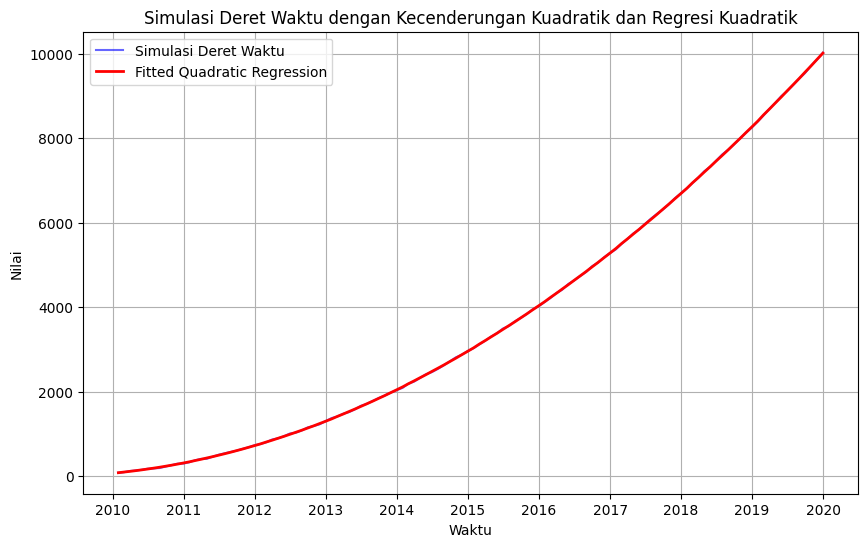

In [87]:
# Prediksi menggunakan model yang sudah dilatih
data_pred = model_quad.predict(X)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(df_quad.Date, df_quad['Value'], label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(df_quad.Date, data_pred, label='Fitted Quadratic Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik dan Regresi Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

***Cek apakah model regresi kuadratik yang dipaskan terhadap sudah memenuhi asumsi-asumsi model!***

Berdasarkan hasil pengepasan model regresi kuadratik, model telah mampu menggambarkan pola kecenderungan kuadratik pada deret dengan sangat baik. Nilai estimasi parameter $\hat{\beta}_0$, $\hat{\beta}_1$, dan $\hat{\beta}_2$ sangat dekat dengan parameter asli, yaitu $\beta_0=79$, $\beta_1=14.5$, dan $\beta_2=0.58$. Nilai $R^2$ yang mendekati 1 menunjukkan bahwa hampir seluruh variasi deret dapat dijelaskan oleh model kuadratik, serta seluruh koefisien regresi signifikan secara statistik.

---

***Apakah model yang dipaskan terhadap deret sudah tepat? Jelaskan jawaban Anda!***

Oleh karena itu, model regresi kuadratik yang dipaskan sudah sesuai untuk menjelaskan pola deret yang memiliki kecenderungan kuadratik.

In [126]:
# cek asumsi model regresi kuadratik
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson

# Uji normalitas Shapiro-Wilk
shapiro_quad = stats.shapiro(model_quad.resid)

# Uji homoskedastisitas Breusch-Pagan
bp_quad = het_breuschpagan(
    model_quad.resid,
    model_quad.model.exog
)

# Uji autokorelasi Ljung-Box
ljung_quad = acorr_ljungbox(
    model_quad.resid,
    lags=range(1,20),
    return_df=True
)

# Durbin-Watson
dw_quad = durbin_watson(model_quad.resid)

print(f"Shapiro-Wilk p-value : {shapiro_quad.pvalue:.4f}")
print(f"Breusch-Pagan p-value: {bp_quad[1]:.4f}")
print(f"Durbin-Watson         : {dw_quad:.4f}")
print("\nLjung-Box:")
print(ljung_quad)

Shapiro-Wilk p-value : 0.3946
Breusch-Pagan p-value: 0.5259
Durbin-Watson         : 2.0646

Ljung-Box:
      lb_stat  lb_pvalue
1    0.156410   0.692483
2    0.503036   0.777619
3    0.503078   0.918215
4    0.655999   0.956642
5    0.997773   0.962745
6    0.997777   0.985696
7    0.997885   0.994863
8    1.184073   0.996797
9    2.260242   0.986652
10   3.512265   0.966680
11   3.518270   0.981956
12   3.675217   0.988610
13   5.403428   0.965206
14   7.765680   0.901173
15   7.809395   0.931197
16   8.604464   0.928805
17  11.619774   0.822595
18  12.229333   0.835174
19  12.229603   0.875578


## Kecenderungan Musiman/Siklik

Misalkan suatu deret waktu memiliki nilaitengah $\mu_t$ yang didefinisikan sebagai berikut:

$\mu_t=\beta_0+\beta_1 cos(2\pi f t)+\beta_2 sin(2\pi ft)$

Deret tersebut memiliki kecenderungan kosinus yang berpola musiman.

Bentuk lain fungsi nilaitengah dari kecenderungan musiman (misalnya untuk data bulanan) adalah $\mu_t$ berupa suatu konstanta sejumlah 12 yang nilai berbeda-beda. Nilai ini diinterpretasikan sebagai nilai harapan rata-rata data untuk masing-masing bulan, atau dapat dituliskan sebagai berikut:

$\mu_t=\beta_1$ , untuk $t=1,13,25,...$
       
$\mu_t=\beta_2$ , untuk $t=2,14,26,...$

$.$

$.$

$.$

$\mu_t=\beta_{12}$ , $untuk t=12,24,36,...$


In [90]:
# Menentukan parameter simulasi
np.random.seed(1029)
n_periods = 120
beta0, beta1, beta2=50 + 29, -25 * 29, -2 * 29
freq=1/12

# Membuat komponen musiman
time = np.arange(n_periods)
seasonal_component = beta0+ beta1*np.cos(2*np.pi*time*freq)+beta2*np.sin(2*np.pi*time*freq)

# Menambahkan noise acak
noise = np.random.normal(0, 2, n_periods)

# Simulasi data dengan hanya komponen musiman dan noise (tanpa tren)
data = seasonal_component + noise

# Membuat index waktu (misalnya menggunakan bulan)
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')

# Membuat DataFrame untuk mempermudah analisis dan visualisasi
df_seasonal = pd.DataFrame({'Date': dates, 'Value': data})


In [91]:
df_seasonal["Seasonal_Component"] = seasonal_component
df_seasonal.head()

,Date,Value,Seasonal_Component
0,2010-01-31,-646.199257,-646.000000
1,2010-02-28,-578.881943,-577.868418
2,2010-03-31,-331.986155,-333.729473
3,2010-04-30,21.386707,21.000000
4,2010-05-31,391.544214,391.270527


In [92]:
# Plot data deret waktu
fig = go.Figure()

# Deret aktual
fig.add_trace(
    go.Scatter(
        x=df_seasonal["Date"],
        y=df_seasonal["Value"],
        mode="lines+markers",
        name="Deret Aktual",
        line=dict(
            color="#1f77b4"
        )
    )
)

# Komponen musiman
fig.add_trace(
    go.Scatter(
        x=df_seasonal["Date"],
        y=df_seasonal["Seasonal_Component"],
        mode="lines",
        name="Komponen Musiman",
        line=dict(
            color="#ff7f0e",
            width=3
        )
    )
)
fig.update_layout(
    title="Simulasi Deret Waktu dengan Kecenderungan Musiman",
    xaxis_title="Waktu",
    yaxis_title="Nilai Deret",
    template="simple_white",
    width=900,
    height=450
)
fig.show()

***Misalkan deret tersebut merupakan deret musiman dengan periode musiman 12. Bagaimana Anda menginterpretasikan pola yang terlihat dalam deret tersebut?***

Berdasarkan plot tersebut, deret menunjukkan pola musiman dengan periode 12, ditandai dengan adanya pola naik dan turun yang berulang secara konsisten setiap 12 periode. Deret musiman ini tidak memiliki kecenderungan tren, karena nilai deret berpusat di sekitar nilai rata-rata yang relatif tetap, serta jarak antara nilai tertinggi dan terendah pada setiap siklus relatif sama. Hal ini menunjukkan bahwa variasi musiman bersifat stabil dari waktu ke waktu dan sesuai dengan karakteristik model musiman aditif.

In [93]:
# membuat dummy variabel musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
musim= Seasonality(12, initial_period=1).in_sample(df_seasonal.index)
musim.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [94]:
musim

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [95]:
# pengepasan model regresi tanpa intercept
musiman=sm.OLS(df_seasonal["Value"],musim).fit()

In [96]:
print(musiman.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 6.892e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          2.97e-256
Time:                        13:43:24   Log-Likelihood:                -249.94
No. Observations:                 120   AIC:                             523.9
Df Residuals:                     108   BIC:                             557.3
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari     -647.2058      0.647   -999.585      0.0

***Bagaimana interpretasi dari hasil tersebut?***

Dari hasil estimasi terlihat bahwa:

* Nilai rata-rata tertinggi terjadi pada bulan Juli sebesar sekitar 803.98, diikuti bulan Agustus sebesar sekitar 735.72.
* Nilai rata-rata terendah terjadi pada bulan Januari sebesar sekitar -647.21, diikuti bulan Februari sebesar sekitar -578.88.

Perbedaan nilai rata-rata yang besar antarbulan menunjukkan adanya pola musiman yang kuat dengan periode 12.

Nilai $R^2$ yang mendekati 1 menunjukkan bahwa hampir seluruh variasi dalam deret dapat dijelaskan oleh perbedaan pola musiman antarbulan. Dengan demikian, model regresi musiman tanpa intersep mampu menangkap pola musiman pada deret dengan sangat baik.

In [97]:
# Analisis Sisaan
# mendapatkan sisaan terbakukan
influence=musiman.get_influence()
std_resid=influence.resid_studentized_internal

mapping={1:'$J$',2:'$F$',3:'$M$',
 4:'$A$',5:'$M$',6:'$J$',
 7:'$J$',8:'$A$',9:'$S$',
 10:'$O$',11:'$N$',12:'$D$'}

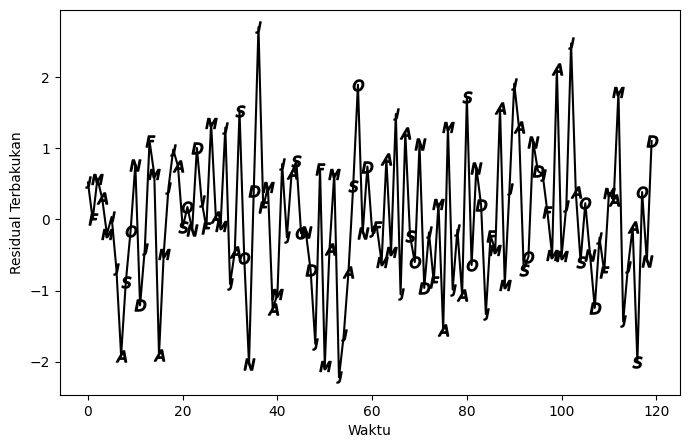

In [98]:
#memetakan sisaan dengan bentuk plot sesuai simbol bulan/musim
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
 plt.plot(i, std_resid[i], marker=mapping[i%12+1],
 color='black', markersize=8)

#membuat plot sisaan terbakukan
plt.plot(std_resid, color='black')
plt.xlabel('Waktu'), plt.ylabel('Residual Terbakukan')
plt.show()


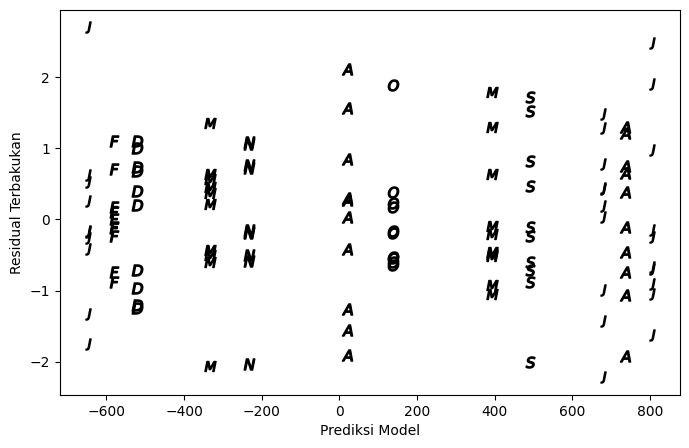

In [99]:
# membuat plot fittedvalues dengan residual terbakukan dengan simbol bulan
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
  plt.plot(musiman.fittedvalues.values[i],
           std_resid[i], marker=mapping[i%12+1],
           color='black', markersize=8)
plt.xlabel('Prediksi Model'),plt.ylabel('Residual Terbakukan')
plt.show()

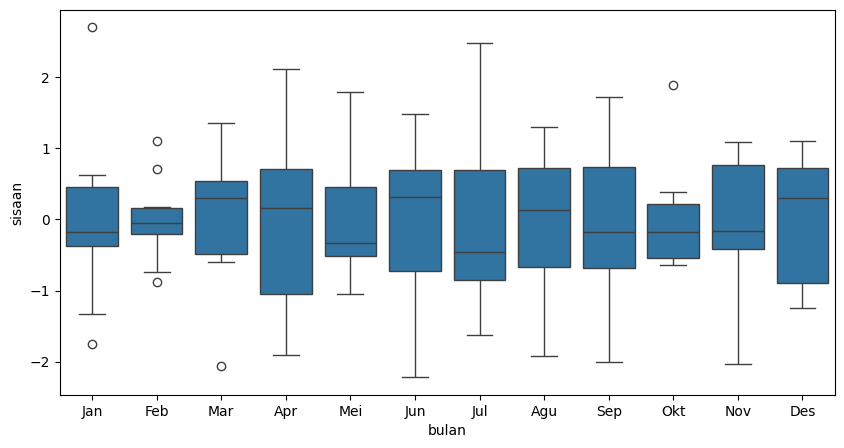

In [127]:
#membuat list daftar bulan
bulan=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']*10

#membuat dataframe untuk mengidentifikasi sisaan dan periode bulannya
box_sisaan=pd.DataFrame(zip(bulan, std_resid),
columns=['bulan','sisaan'])

#membuat boxplot per buln
plt.figure(figsize=(10,5))
sns.boxplot(x='bulan',y='sisaan',data=box_sisaan)
plt.show()

***Bagaimana interpretasi Anda terhadap tiga plot di atas?***

**Residual Terbakukan vs Waktu**
* Plot residual terhadap waktu menunjukkan bahwa residual tersebar secara acak di sekitar nilai nol dan tidak membentuk pola tertentu. Hal ini mengindikasikan bahwa tidak terdapat komponen tren maupun pola musiman tambahan yang belum dijelaskan oleh model.

**Residual Terbakukan vs Prediksi Model**
* Plot residual terhadap nilai prediksi model menunjukkan bahwa residual menyebar secara acak pada seluruh rentang nilai prediksi. Tidak adanya pola tertentu menunjukkan bahwa model telah mampu menjelaskan variasi musiman dengan baik dan secara visual tidak terlihat indikasi heteroskedastisitas pada residual. Kesimpulan mengenai kesamaan ragam residual selanjutnya diperkuat melalui uji Breusch-Pagan.

**Boxplot Residual per Bulan**
* Boxplot residual berdasarkan bulan menunjukkan bahwa residual pada setiap bulan memiliki distribusi yang relatif seimbang di sekitar nol. Tidak terdapat pola residual yang sistematis pada bulan tertentu, sehingga model musiman telah mampu menangkap perbedaan pola antar bulan dengan baik.


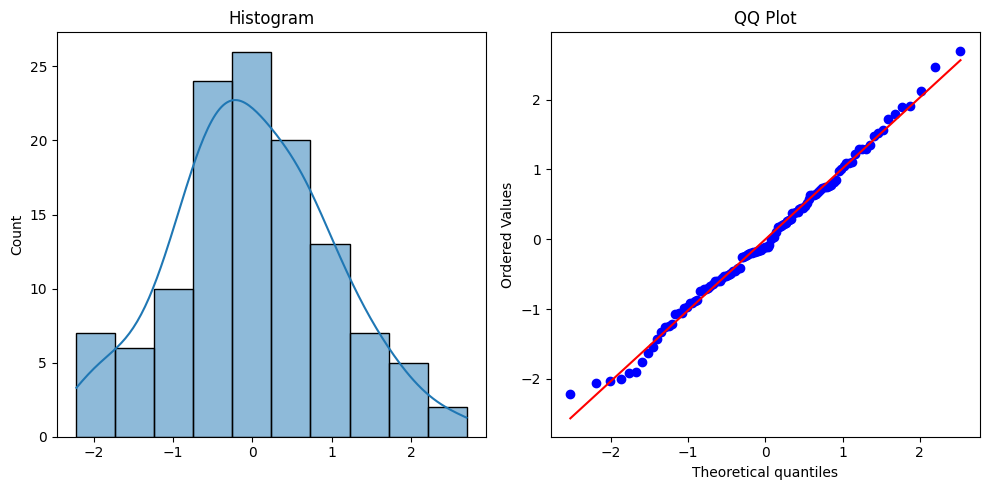

In [101]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(std_resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

***Berdasarkan plot-plot tersebut apakah dapat dikatakan bahwa model yang dipaskan sudah tepat?***

Berdasarkan histogram residual dan QQ Plot, residual dari model regresi musiman menunjukkan pola yang mendekati distribusi normal. Histogram terlihat relatif simetris dan sebagian besar titik pada QQ Plot mengikuti garis diagonal. Dengan demikian, secara visual tidak terdapat indikasi kuat adanya pelanggaran asumsi normalitas. Namun, ketepatan model tidak cukup dinilai berdasarkan normalitas residual saja, sehingga perlu diperkuat dengan pemeriksaan asumsi homoskedastisitas dan independensi residual.

***Hitunglah statistik uji untuk mengecek asumsi model***



In [128]:
# hitung statistik uji untuk mengecek asumsi model tanpa intersep

# Uji asumsi model musiman tanpa intersep

# Normalitas
shapiro_musim = stats.shapiro(musiman.resid)

# Untuk Breusch-Pagan gunakan representasi model yang ekuivalen
X_bp_musim = sm.add_constant(musim.iloc[:, 1:])

bp_musim = het_breuschpagan(
    musiman.resid,
    X_bp_musim
)

# Autokorelasi
ljung_musim = acorr_ljungbox(
    musiman.resid,
    lags=range(1,20),
    return_df=True
)

dw_musim = sm.stats.stattools.durbin_watson(
    musiman.resid
)

print(f"Shapiro-Wilk p-value : {shapiro_musim.pvalue:.4f}")
print(f"Breusch-Pagan p-value: {bp_musim[1]:.4f}")
print(f"Durbin-Watson         : {dw_musim:.4f}")
print("\nLjung-Box:")
print(ljung_musim)

Shapiro-Wilk p-value : 0.7850
Breusch-Pagan p-value: 0.5818
Durbin-Watson         : 2.1355

Ljung-Box:
      lb_stat  lb_pvalue
1    0.671604   0.412493
2    0.871036   0.646929
3    0.914956   0.821817
4    0.923220   0.921206
5    0.994890   0.962977
6    0.995530   0.985781
7    1.098800   0.993074
8    1.736119   0.988061
9    2.876534   0.968989
10   3.869652   0.953036
11   3.960773   0.971050
12   6.312060   0.899541
13   7.791734   0.856899
14  10.424551   0.730532
15  10.513122   0.786283
16  10.804224   0.821405
17  13.288091   0.716697
18  14.474031   0.697708
19  14.534820   0.751669


In [102]:
# pengepasan model regresi dengan intersep
musiman_int=sm.OLS(df_seasonal["Value"],sm.add_constant(musim.iloc[:,1:])).fit()

In [103]:
print(musiman_int.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 6.892e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          2.97e-256
Time:                        13:44:23   Log-Likelihood:                -249.94
No. Observations:                 120   AIC:                             523.9
Df Residuals:                     108   BIC:                             557.3
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -647.2058      0.647   -999.585      0.0

***Perhatikan hasil pengepasan model dengan intersep. Bandingkan hasilnya dengan pengepasan tanpa intersep. Bagaimana interpretasi model dengan intersep dibandingkan model tanpa intersep? Jelaskan cara memaknai nilai koefisien regresi yang diperoleh!***

* **Model dengan Intersep**

Januari dijadikan kategori referensi. Intersep sebesar -647.2058 menunjukkan rata-rata Januari, sedangkan koefisien bulan lain menunjukkan selisih rata-rata bulan tersebut terhadap Januari. Sebagai contoh, koefisien Februari sebesar 68.3269 berarti rata-rata Februari sekitar 68.33 satuan lebih tinggi daripada Januari, sehingga nilai rata-rata Februari adalah -647.2058+68.3269=-578.8789. Koefisien Juli sebesar 1451.1848 berarti rata-rata Juli sekitar 1451.18 satuan lebih tinggi daripada Januari.

* **Model Tanpa Intersep**

Setiap koefisien bulan langsung menunjukkan rata-rata nilai deret pada bulan tersebut. Sebagai contoh, koefisien Januari sebesar -647.2058 merupakan rata-rata nilai deret pada bulan Januari, sedangkan koefisien Juli sebesar 803.9790 merupakan rata-rata nilai pada bulan Juli.

Model dengan dan tanpa intersep menghasilkan fitted values, residual, dan $R^2$ yang sama. Perbedaannya hanya pada cara parameterisasi dan interpretasi koefisien.

***Apakah model dengan intersep sudah memenuhi asumsi regresi***?

Model dengan intersep menghasilkan fitted values, residual, dan nilai $R^2$ yang sama dengan model tanpa intersep, sehingga kemampuan kedua model dalam menjelaskan data juga sama. Nilai $R^2$ yang mendekati 1 menunjukkan bahwa hampir seluruh variasi deret dapat dijelaskan oleh pola musiman. Karena kedua model hanya berbeda dalam parameterisasi, hasil pengecekan asumsi residual juga seharusnya sama. Berdasarkan pemeriksaan normalitas, homoskedastisitas, dan independensi residual, tidak ditemukan indikasi pelanggaran asumsi regresi. Dengan demikian, model musiman dengan intersep juga sesuai untuk menggambarkan pola deret.

In [104]:
# uji asumsi model dengan intersep

## Kecenderungan Linear dan Musiman

In [105]:
# Parameter
np.random.seed(1029)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.5 * 29, 10 * 29 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=2, size=n)

# Gabungan semua komponen
series = trend + seasonality + noise


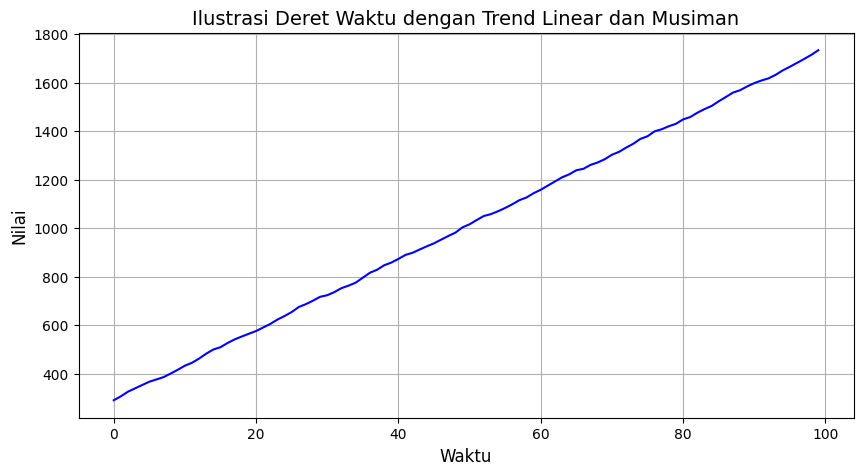

In [106]:
plt.figure(figsize=(10, 5))
plt.plot(x, series, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman', fontsize=14)
plt.grid()
plt.show()

Untuk deret tersebut, dibutuhkan model yang mampu menangkap kecenderungan linear (tren) sekaligus kecenderungan musiman dalam deret. Salah satu model sederhana yang dapat digunakan adalah model regresi linear dengan variabel musiman.

In [107]:
df_mix_component = pd.DataFrame({
    "Time": x,
    "Trend": trend,
    "Seasonal": seasonality,
    "Series": series
})

df_mix_component.head()

,Time,Trend,Seasonal,Series
0,0,290.0,0.000000,289.800743
1,1,304.5,2.500000,305.986475
2,2,319.0,4.330127,325.073446
3,3,333.5,5.000000,338.886707
4,4,348.0,4.330127,352.603815


In [109]:
# mengubah data menjadi format dataframe
df_mix = pd.DataFrame(series, columns=['Value'])

# mengekstrak komponen musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
season= Seasonality(12, initial_period=1).in_sample(df_mix.index)
season.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [110]:
season['period']=x
model_mix=sm.OLS(series,season).fit()

In [111]:
print(model_mix.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.490e+05
Date:                Sat, 05 Sep 2026   Prob (F-statistic):          3.69e-198
Time:                        13:46:24   Log-Likelihood:                -206.49
No. Observations:                 100   AIC:                             439.0
Df Residuals:                      87   BIC:                             472.9
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari      288.6017      0.762    378.592      0.0

***Bagaimana cara menginterpretasikan nilai koefisien regresi yang diperoleh dalam model regresi tersebut?***

Koefisien period sebesar 14.5052 menunjukkan bahwa setelah memperhitungkan pengaruh musiman, nilai deret meningkat sekitar 14.51 satuan untuk setiap kenaikan satu periode waktu. Nilai tersebut sangat dekat dengan parameter tren asli a=14.5. Koefisien Januari hingga Desember berperan sebagai level dasar masing-masing musim pada model tanpa intersep umum. Perbedaan koefisien antarbulan menunjukkan adanya pola musiman, dengan level relatif lebih tinggi sekitar Maret–Mei dan lebih rendah sekitar September–November. Dengan demikian, model mampu menangkap kecenderungan linear melalui period dan kecenderungan musiman melalui perbedaan koefisien antarbulan.

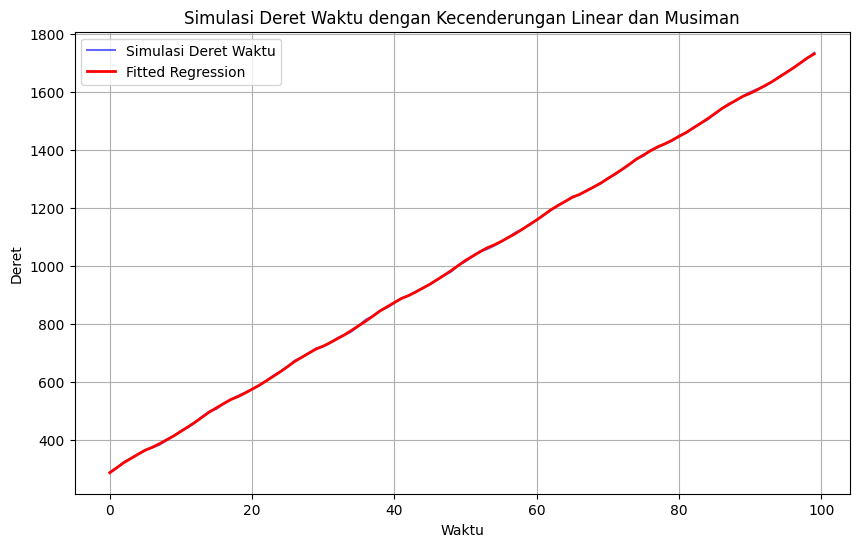

In [112]:
# Prediksi menggunakan model yang sudah dilatih
pred_mix = model_mix.predict(season)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(x, series, label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(x, pred_mix, label='Fitted Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Linear dan Musiman')
plt.xlabel('Waktu')
plt.ylabel('Deret')
plt.legend()
plt.grid(True)
plt.show()

***Lakukan pengecekan asumsi model! Jelaskan apakah hasil menunjukkan ada pelanggaran asumsi dalam model!***



In [129]:
# uji asumsi model

# Residual model
resid_mix = model_mix.resid

# Normalitas
shapiro_mix = stats.shapiro(resid_mix)

# Breusch-Pagan
# Gunakan parameterisasi ekuivalen dengan konstanta eksplisit
X_bp_mix = sm.add_constant(
    season.drop(columns='Januari')
)

bp_mix = het_breuschpagan(
    resid_mix,
    X_bp_mix
)

# Autokorelasi
ljung_mix = acorr_ljungbox(
    resid_mix,
    lags=range(1,20),
    return_df=True
)

dw_mix = sm.stats.stattools.durbin_watson(
    resid_mix
)

print(f"Shapiro-Wilk p-value : {shapiro_mix.pvalue:.4f}")
print(f"Breusch-Pagan p-value: {bp_mix[1]:.4f}")
print(f"Durbin-Watson         : {dw_mix:.4f}")
print("\nLjung-Box:")
print(ljung_mix)

Shapiro-Wilk p-value : 0.9780
Breusch-Pagan p-value: 0.6664
Durbin-Watson         : 2.1005

Ljung-Box:
      lb_stat  lb_pvalue
1    0.555261   0.456176
2    0.931284   0.627732
3    1.057630   0.787311
4    1.691840   0.792199
5    1.776146   0.879170
6    1.798060   0.937303
7    1.840929   0.968118
8    2.508506   0.961333
9    3.038951   0.962731
10   3.909639   0.951331
11   4.003463   0.969816
12   8.947338   0.707422
13  11.165739   0.596935
14  11.424556   0.652409
15  11.437103   0.721038
16  11.730220   0.762333
17  12.548304   0.765860
18  13.384300   0.768256
19  14.351400   0.762835


Saat melihat plot dari suatu deret, terkadang kita tidak yakin komponen apa saja yang ada dalam deret. Misalkan, apakah deret tidak memuat tren? apakah ada tren? apakah ada komponen musiman? Untuk memastikan komponen apa saja yang ada dalam suatu deret, dapat dilakukan dengan dekomposisi deret. Dekomposisi deret bertujuan menguraikan deret menjadi 3 komponen, yaitu tren, musiman, dan noise.

In [113]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Value'], model='additive', period=12)

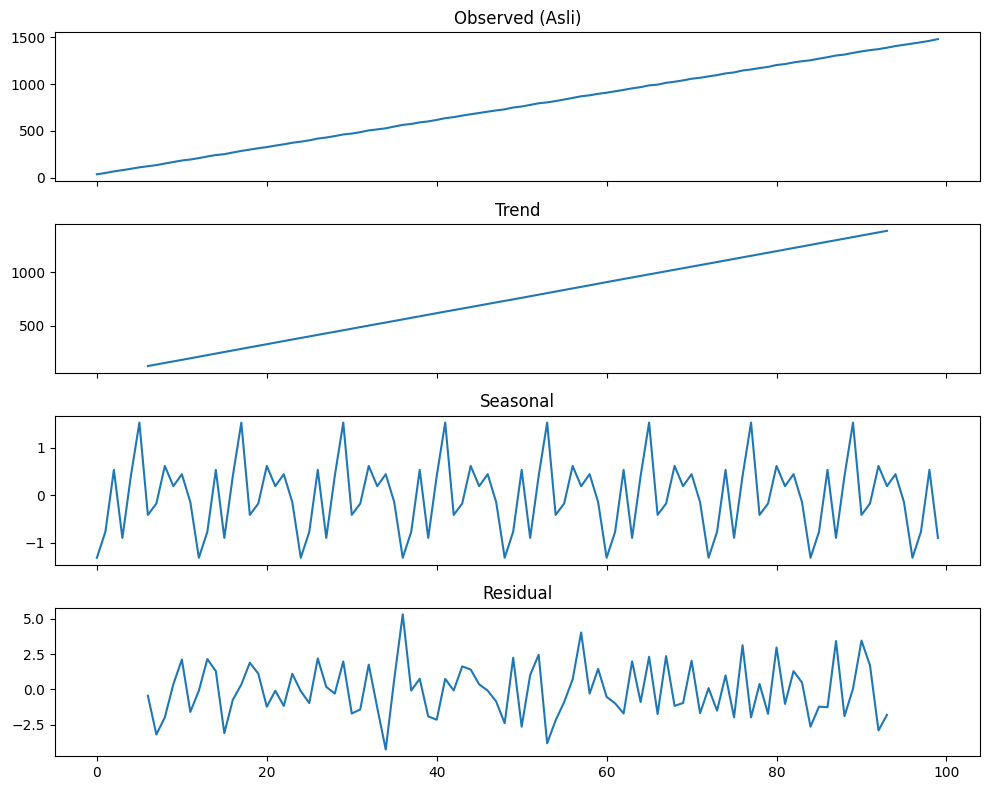

In [114]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

***Bagaimana interpretasi hasil dekomposisi deret tersebut?***

Pada bagian Observed, terlihat nilai deret meningkat secara konsisten dari waktu ke waktu. Pola ini menunjukkan bahwa karakteristik utama deret adalah kecenderungan linear positif. Pada komponen Trend, terlihat garis yang meningkat hampir lurus dan sangat mirip dengan pola pada deret asli. Hal ini menunjukkan bahwa sebagian besar perubahan pada deret dapat dijelaskan oleh komponen tren. Pada komponen Seasonal, terlihat fluktuasi kecil di sekitar nol. Pada bagian Residual, nilai residual berfluktuasi secara acak di sekitar nol dan tidak terlihat adanya tren atau pola sistematis tertentu.

Dengan demikian, pola utama pada deret tersebut adalah kecenderungan linear, sesuai dengan struktur data yang digunakan pada simulasi.

In [115]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear dan musiman
from statsmodels.tsa.seasonal import seasonal_decompose
result_mix = seasonal_decompose(df_mix['Value'], model='additive', period=12)

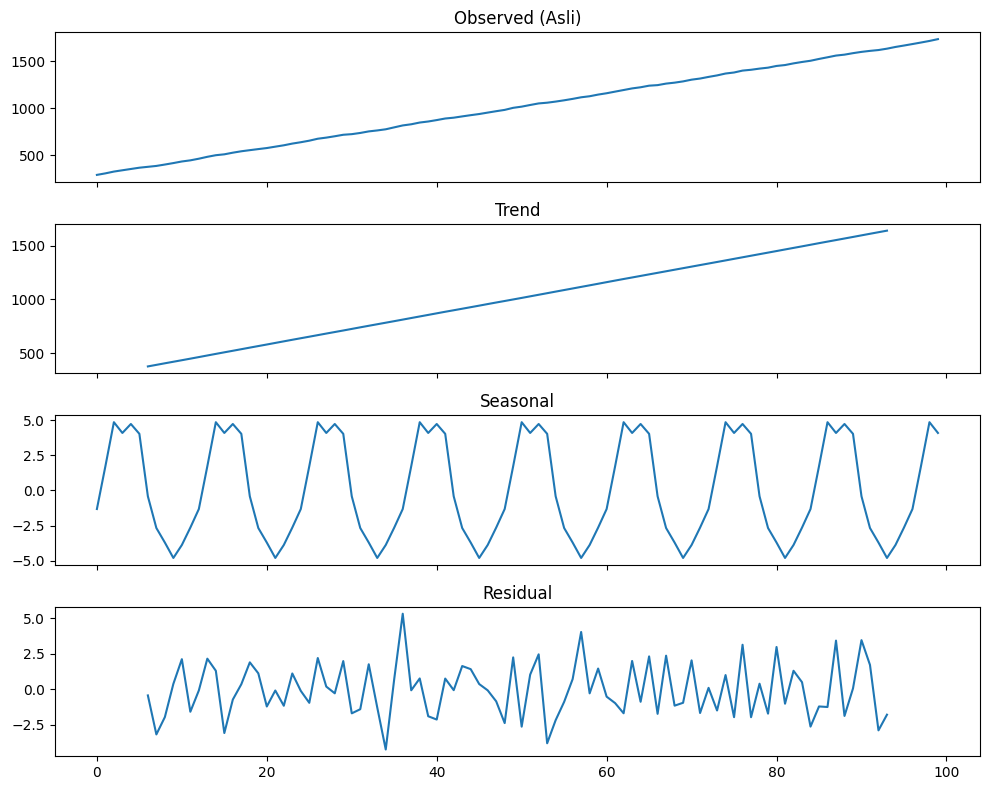

In [116]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result_mix.observed.plot(ax=axes[0], title='Observed (Asli)')
result_mix.trend.plot(ax=axes[1], title='Trend')
result_mix.seasonal.plot(ax=axes[2], title='Seasonal')
result_mix.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()


***Bagaimana interpretasi hasil dekomposisi deret tersebut?***

Hasil dekomposisi menunjukkan bahwa deret memiliki dua komponen utama, yaitu kecenderungan linear yang meningkat dan pola musiman yang berulang secara teratur. Setelah kedua komponen tersebut dipisahkan, residual terlihat relatif acak di sekitar nol. Dengan demikian, dekomposisi berhasil memisahkan struktur tren dan musiman dari deret, dan hasilnya sesuai dengan karakteristik data simulasi yang memang dibentuk dari komponen tren linear, musiman, dan noise.

Ketika melakukan dekoposisi deret, perlu diperhatikan bahwa terdapat 2 jenis model untuk dekomposisi, yaitu model `Aditif` dan `multiplikatif`.

- Model `aditif` digunakan jika ragam deret relatif konstan atau kecil

- Model `multiplikatif` digunakan jika ragam deret besar

In [117]:
# ilustrasi untuk deret multiplikatif
# Parameter
np.random.seed(1029)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.05 * 29, 10 * 29 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 1+ 0.5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=0.2, size=n)

# Gabungan semua komponen
series_multi = trend*seasonality + noise

In [118]:
fig = go.Figure()

# Deret aktual
fig.add_trace(
    go.Scatter(
        x=x,
        y=series_multi,
        mode='lines+markers',
        name='Deret Aktual',
        line=dict(color='#1f77b4')
    )
)

# Trend
fig.add_trace(
    go.Scatter(
        x=x,
        y=trend,
        mode='lines',
        name='Trend Linear',
        line=dict(
            color='#ff7f0e',
            width=3
        )
    )
)
fig.update_layout(
    title='Deret Waktu dengan Trend Linear dan Musiman Multiplikatif',
    xaxis_title='Waktu',
    yaxis_title='Nilai Deret',
    template='simple_white',
    width=900,
    height=450
)
fig.show()

Dekomposisi dengan model multiplikatif hanya bisa dilakukan untuk deret dengan nilai >0, sehingga jika deret memiliki nilai 0 atau negatif maka deret perlu ditransformasi.

In [119]:
#  Dekomposisi dengan model multiplikatif
# mengubah data menjadi format dataframe
df_multi = pd.DataFrame(series_multi, columns=['Value'])

from statsmodels.tsa.seasonal import seasonal_decompose
result_multi = seasonal_decompose(df_multi['Value'], model='multiplicative', period=12)

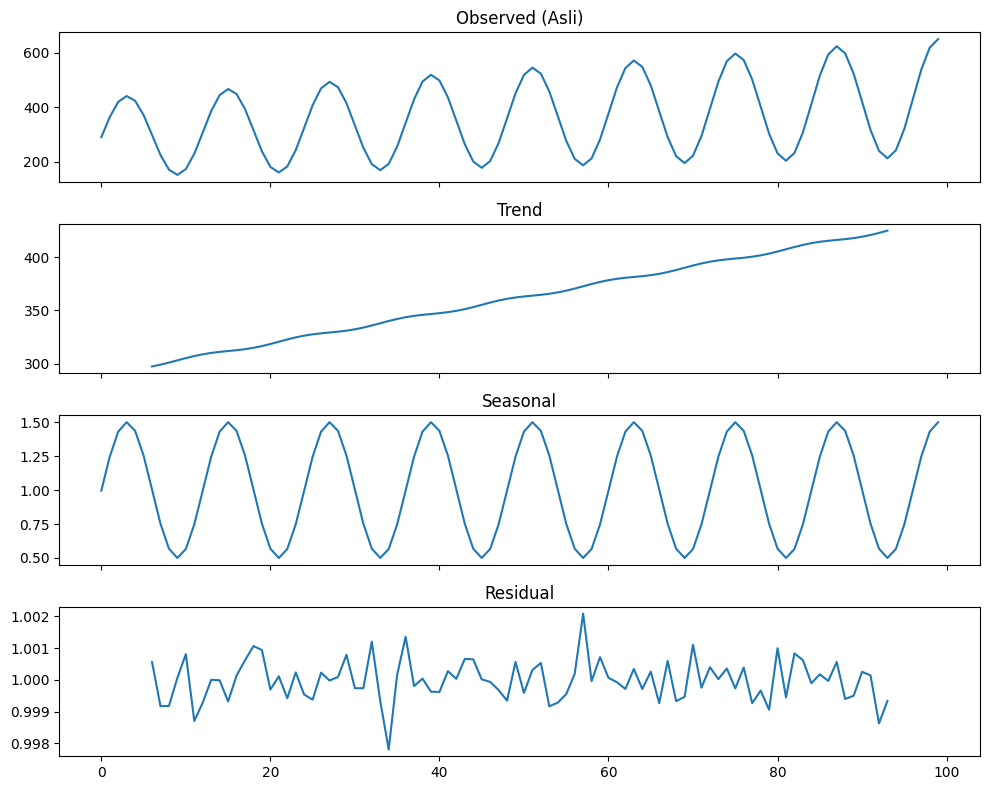

In [120]:
# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_multi.observed.plot(ax=axes[0], title='Observed (Asli)')
result_multi.trend.plot(ax=axes[1], title='Trend')
result_multi.seasonal.plot(ax=axes[2], title='Seasonal')
result_multi.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

***Bagaimana Anda menginterpretasikan plot hasil dekomposisi tersebut?***

Hasil dekomposisi menunjukkan bahwa deret memiliki tren meningkat dan pola musiman dengan periode 12 yang konsisten. Besarnya fluktuasi pada deret semakin meningkat seiring meningkatnya level tren, sehingga karakteristik deret sesuai dengan model multiplikatif. Komponen seasonal berperan sebagai faktor pengali terhadap tren, sedangkan residual sebagian besar berada di sekitar 1 dan tidak menunjukkan pola sistematis yang kuat. Dengan demikian, dekomposisi multiplikatif mampu memisahkan komponen tren, musiman, dan variasi acak pada deret dengan baik.

In [122]:
# Parameter
np.random.seed(1029)
n = 100  # Jumlah titik data
x = np.arange(n)

# Hanya noise acak tanpa trend atau musiman
noise = np.random.normal(loc=10, scale=2, size=n)  # Nilai acak sekitar 10

# Buat DataFrame untuk regresi
df = pd.DataFrame({'Time': x, 'Series': noise})
df['Time'] = pd.to_datetime(df['Time'], unit='D')  # Konversi ke format waktu
df.set_index('Time', inplace=True)

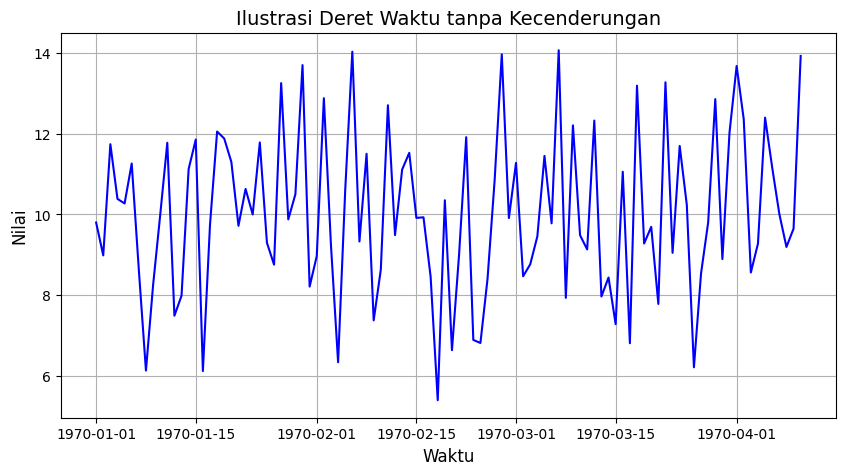

In [124]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Series'], color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu tanpa Kecenderungan', fontsize=14)
plt.grid()
plt.show()

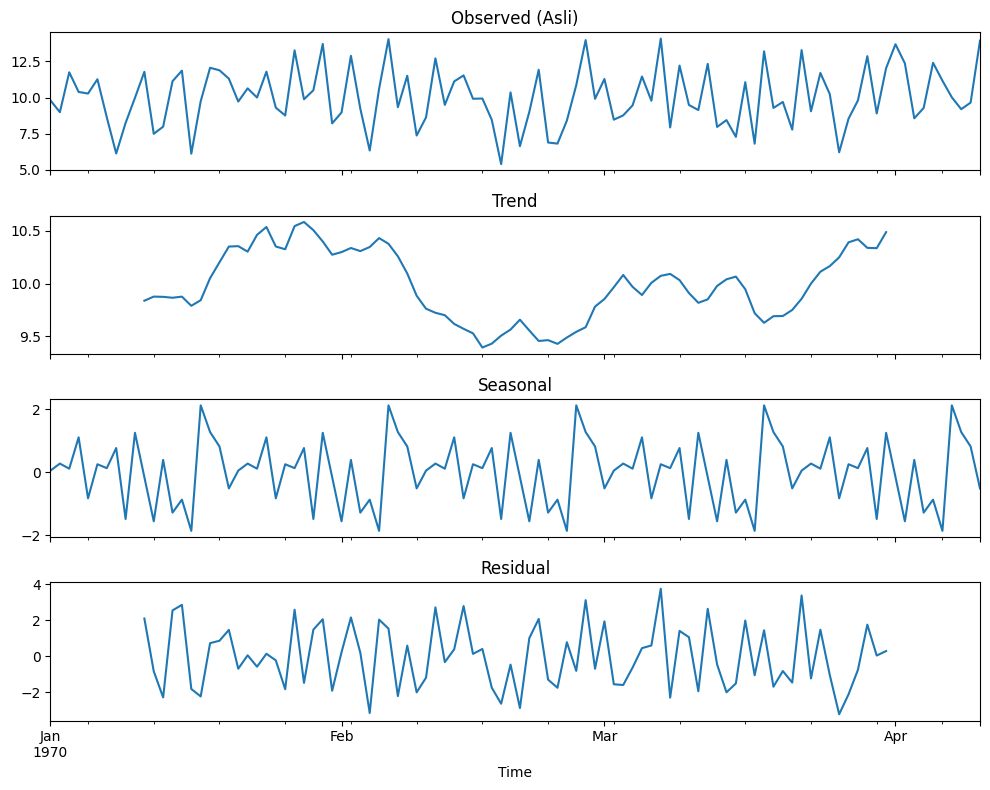

In [125]:
# Lakukan dekomposisi dengan model aditif
result = seasonal_decompose(df['Series'], model='additive', period=20)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

***Bagaimana interpretasi dari plot tersebut?***

Deret pada dasarnya tidak memiliki kecenderungan tren maupun musiman yang jelas dan hanya berfluktuasi di sekitar nilai rata-rata yang relatif konstan. Meskipun hasil dekomposisi menampilkan komponen trend dan seasonal, pola tersebut relatif lemah dan dapat muncul akibat proses pemisahan komponen oleh metode dekomposisi. Dengan demikian, karakteristik utama deret ini adalah variasi acak atau noise, sesuai dengan proses pembangkitan datanya.